<a href="https://colab.research.google.com/github/256-katendechris-256/Job_App/blob/main/anemia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.6/684.6 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.1/979.1 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 12.3 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.2.0
    Uninstalling python-box-7.2.0:
      Successfully uninstalled python-box-7.2.0


In [25]:
from comet_ml import Experiment
from comet_ml.integration.pytorch import log_model

experiment = Experiment(
    api_key ='1ifpXvXZt8USEKZIlxVIvBnBt',
    project_name='genral',
    workspace= '256-katendechris-256'
)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: keras, tensorflow, sklearn.
COMET WARNING: Couldn't retrieve Google Colab notebook content
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : elated_galliform_5025
COMET INFO:     url                   : https://www.comet.com/256-katendechris-256/genral/1fdf30beb97843d9b607d1b7e1193ecb
COMET INFO:   Metrics:
COMET INFO:     accuracy : 3.14
COMET INFO:   Parameters:
COMET INFO:     batch_size        : 50
COMET INFO:     hidden_layer_size : 50
COMET INFO:     learning_rate     : 0.5
COMET INFO:     steps             : 100000
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     fi

In [26]:
import os
import cv2
import numpy as np

# Function to load and preprocess images from a given directory
def load_and_preprocess_images(dataset_path):
    # Get a list of all subfolders
    subfolders = os.listdir(dataset_path)

    # Initialize empty lists for images and labels
    images = []
    labels = []

    # Iterate through each subfolder
    for subfolder in subfolders:
        # Get the path to the current subfolder
        subfolder_path = os.path.join(dataset_path, subfolder)

        # Get a list of all files in the current subfolder
        files = os.listdir(subfolder_path)

        # Iterate through each file in the current subfolder
        for file in files:
            # Check if the file is an image
            if file.endswith(".jpg") or file.endswith(".png"):
                # Get the path to the current image
                image_path = os.path.join(subfolder_path, file)

                # Read the image
                image = cv2.imread(image_path)

                # Resize the image
                image = cv2.resize(image, (224, 224))

                # Convert the image to a NumPy array
                image = np.array(image)

                # Append the original image and its label to the lists
                images.append(image)
                labels.append(subfolder)

    # Convert the lists to NumPy arrays
    images = np.array(images)
    labels = np.array(labels)

    # Preprocess the images(Normalize)
    preprocessed_images = images / 255.0

    return preprocessed_images, labels

# Define the paths to the datasets
negative_dataset_path = "/content/drive/MyDrive/sickle cell uganda 2024-20240415T165932Z-001/sickle cell uganda 2024/Negative"
positive_dataset_path = "/content/drive/MyDrive/sickle cell uganda 2024-20240415T165932Z-001/sickle cell uganda 2024/Positive"

# Load and preprocess images from both datasets
negative_images, negative_labels = load_and_preprocess_images(negative_dataset_path)
positive_images, positive_labels = load_and_preprocess_images(positive_dataset_path)

# Combine the two datasets
combined_images = np.concatenate((negative_images, positive_images), axis=0)
combined_labels = np.concatenate((negative_labels, positive_labels), axis=0)

# Check if the number of images and labels match
print("Number of images:", len(combined_images))
print("Number of labels:", len(combined_labels))


Number of images: 1053
Number of labels: 1053


In [27]:
# prompt: combined_images = np.concatenate((negative_images, positive_images), axis=0) store this in directory

# Import the necessary libraries
import os

# Define the directory where you want to store the combined images
target_directory = "/content/drive/MyDrive/Combined"

# Create the target directory if it doesn't exist
if not os.path.exists(target_directory):
    os.makedirs(target_directory)

# Iterate through the combined images and save them to the target directory
for i, image in enumerate(combined_images):
    # Generate a unique filename for each image
    filename = f"combined_image_{i}.jpg"

    # Construct the full path for the image
    image_path = os.path.join(target_directory, filename)

    # Save the image to the target directory
    cv2.imwrite(image_path, image)



Framework Definition

Found 1053 files belonging to 2 classes.
Using 843 files for training.
Found 1053 files belonging to 2 classes.
Using 210 files for validation.


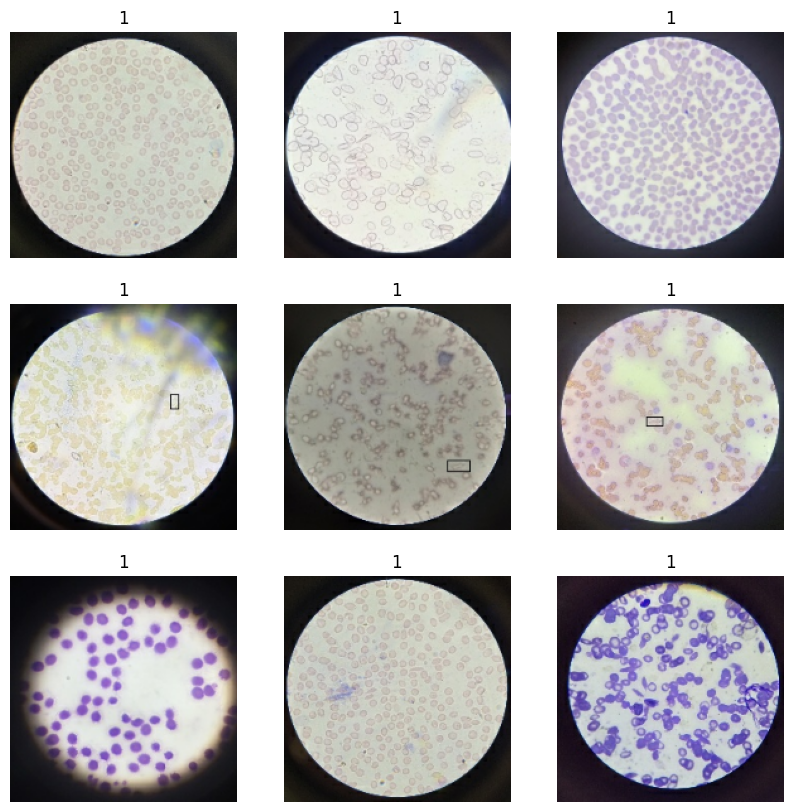

In [28]:
import os
import cv2
import numpy as np

# Function to load and preprocess images from a given directory
def load_and_preprocess_images(dataset_path):
    # Get a list of all subfolders
    subfolders = os.listdir(dataset_path)

    # Initialize empty lists for images and labels
    images = []
    labels = []

    # Iterate through each subfolder
    for subfolder in subfolders:
        # Get the path to the current subfolder
        subfolder_path = os.path.join(dataset_path, subfolder)

        # Get a list of all files in the current subfolder
        files = os.listdir(subfolder_path)

        # Iterate through each file in the current subfolder
        for file in files:
            # Check if the file is an image
            if file.endswith(".jpg") or file.endswith(".png"):
                # Get the path to the current image
                image_path = os.path.join(subfolder_path, file)

                # Read the image
                image = cv2.imread(image_path)

                # Resize the image
                image = cv2.resize(image, (224, 224))

                # Convert the image to a NumPy array
                image = np.array(image)

                # Append the original image and its label to the lists
                images.append(image)
                labels.append(subfolder)

    # Convert the lists to NumPy arrays
    images = np.array(images)
    labels = np.array(labels)

    # Preprocess the images (Normalize)
    preprocessed_images = images / 255.0

    return preprocessed_images, labels

# Define the paths to the datasets
negative_dataset_path = "/content/drive/MyDrive/sickle cell uganda 2024-20240415T165932Z-001/sickle cell uganda 2024/Negative"
positive_dataset_path = "/content/drive/MyDrive/sickle cell uganda 2024-20240415T165932Z-001/sickle cell uganda 2024/Positive"

# Load and preprocess images from both datasets
negative_images, negative_labels = load_and_preprocess_images(negative_dataset_path)
positive_images, positive_labels = load_and_preprocess_images(positive_dataset_path)

# Combine the two datasets
combined_images = np.concatenate((negative_images, positive_images), axis=0)
combined_labels = np.concatenate((negative_labels, positive_labels), axis=0)

# Define the directory where you want to store the combined images
target_directory = "/content/drive/MyDrive/Combined"

# Create the target directory if it doesn't exist
if not os.path.exists(target_directory):
    os.makedirs(target_directory)

# Create subdirectories for each class
negative_class_dir = os.path.join(target_directory, "Negative")
positive_class_dir = os.path.join(target_directory, "Positive")

if not os.path.exists(negative_class_dir):
    os.makedirs(negative_class_dir)

if not os.path.exists(positive_class_dir):
    os.makedirs(positive_class_dir)

# Iterate through the combined images and save them to the target directory
for i, (image, label) in enumerate(zip(combined_images, combined_labels)):
    # Generate a unique filename for each image
    filename = f"combined_image_{i}.jpg"

    # Construct the full path for the image based on its label
    if label == "Negative":
        image_path = os.path.join(negative_class_dir, filename)
    else:
        image_path = os.path.join(positive_class_dir, filename)

    # Save the image to the target directory
    cv2.imwrite(image_path, image * 255)  # Multiply by 255 to restore pixel values

# Import the necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load the dataset
train_dataset = image_dataset_from_directory(
    target_directory,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    target_directory,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32)

# Now you can proceed with the rest of your pipeline
# Example: visualize some images
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()


In [29]:
# prompt: execute code for feature extaction

import numpy as np
# Feature extraction

# Define the feature extraction model
feature_extraction_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(180, 180, 3),
    pooling="avg",
)

# Extract features from the training and validation datasets
train_features = feature_extraction_model.predict(train_dataset)
validation_features = feature_extraction_model.predict(validation_dataset)

# Convert the features to NumPy arrays
train_features = np.array(train_features)
validation_features = np.array(validation_features)

# Print the shapes of the feature arrays
print(f"Train features shape: {train_features.shape}")
print(f"Validation features shape: {validation_features.shape}")


27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 543ms/step
Train features shape: (843, 1280)
Validation features shape: (210, 1280)


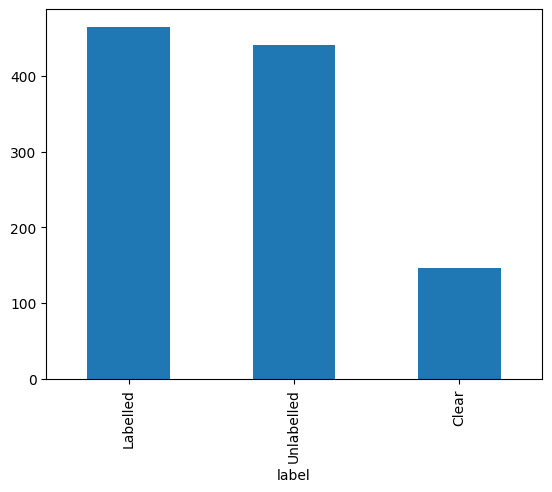

Image shape: (224, 224, 3)
Mean pixel value: 0.5967596240132245
Standard deviation of pixel values: 0.3148447096656257


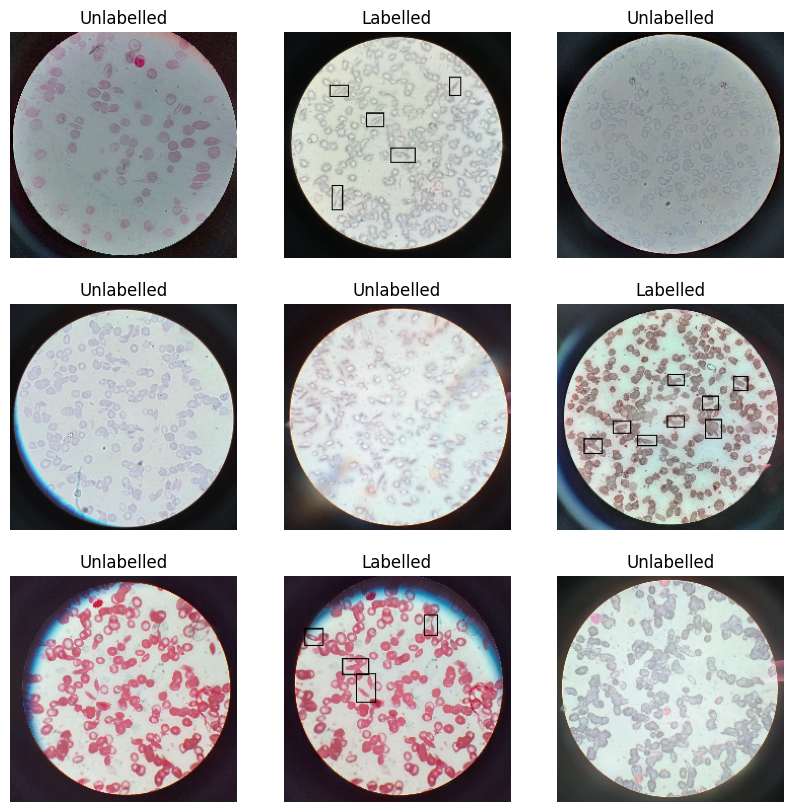

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the dataset into a Pandas DataFrame
df = pd.DataFrame({
    "label": combined_labels,
    "image_path": [os.path.join(target_directory, f"combined_image_{i}.jpg") for i in range(len(combined_images))]
})

# Get some descriptive statistics about the dataset
df.describe()

# Get the number of images for each label
df["label"].value_counts()

# Visualize the distribution of labels
df["label"].value_counts().plot(kind="bar")
plt.show()

# Get the shape of the images
image_shape = combined_images[0].shape
print(f"Image shape: {image_shape}")

# Calculate the mean and standard deviation of the pixel values
mean = np.mean(combined_images)
std = np.std(combined_images)
print(f"Mean pixel value: {mean}")
print(f"Standard deviation of pixel values: {std}")

# Visualize some random images
plt.figure(figsize=(10, 10))
for i in range(9):
    idx = np.random.randint(0, len(combined_images))
    plt.subplot(3, 3, i + 1)
    plt.imshow(combined_images[idx])
    plt.title(combined_labels[idx])
    plt.axis("off")
plt.show()


In [31]:
#Augmentation
from tensorflow.keras import layers, models
#data_augmentation = tf.keras.Sequential([
  #layers.RandomFlip("horizontal_and_vertical"),
  #layers.RandomRotation(0.2),
#])
#
## Apply data augmentation to the training dataset
#train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))


Building the model(CNNs)

In [32]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),  # Normalize pixel values to [0, 1]
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # For binary classification
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

def res2net_block(input_tensor, filters, scale=4):
    """Implements a Res2Net block with split-convolutions."""
    shortcut = input_tensor  # Save for the skip connection

    # Initial 1x1 convolution to reduce dimensions
    x = layers.Conv2D(filters, (1, 1), strides=(1, 1), padding="same")(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    split_channels = filters // scale
    splits = []

    # First segment does not use any convolution
    splits.append(x[:, :, :, :split_channels])

    # Apply convolutions to remaining segments
    for i in range(1, scale):
        if i == 1:
            splits.append(layers.Conv2D(split_channels, (3, 3), padding="same")(x[:, :, :, i * split_channels:(i + 1) * split_channels]))
        else:
            splits.append(layers.Conv2D(split_channels, (3, 3), padding="same")(splits[-1]))

    # Concatenate all segments back together
    x = layers.Concatenate()(splits)

    # Final 1x1 convolution to restore dimensions
    x = layers.Conv2D(filters, (1, 1), strides=(1, 1), padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Ensure the input and output shapes match for the residual connection
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add the residual connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x


In [34]:
def build_res2net(input_shape=(224, 224, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Example Res2Net layers - you can customize this structure
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding="same")(x)

    # Add Res2Net blocks
    x = res2net_block(x, 64, scale=4)
    x = res2net_block(x, 128, scale=4)
    x = res2net_block(x, 256, scale=4)
    x = res2net_block(x, 512, scale=4)

    # Global average pooling and final dense layer
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="sigmoid" if num_classes == 1 else "softmax")(x)

    model = models.Model(inputs, outputs)
    return model


In [35]:
# Define your custom Res2Net model
pretrained_models = [
    build_res2net,  # Res2Net implementation
    # Add other models here if needed
]

for model_class in pretrained_models:
    # Create a new model instance
    model = model_class(input_shape=(180, 180, 3), num_classes=1) # Match the input shape to your dataset

    # Freeze pre-trained layers (in this custom case, you can skip this step if you're training from scratch)
    for layer in model.layers[:-3]:  # Adjust as needed based on the architecture
        layer.trainable = False

    # Compile the model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    # Train the model
    history = model.fit(train_dataset, validation_data=validation_dataset, epochs=3)

    # Evaluate the model
    _, accuracy = model.evaluate(validation_dataset)
    print(f"Model: {model_class.__name__}, Accuracy: {accuracy:.2f}")

Epoch 1/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 291ms/step - accuracy: 1.0000 - loss: 2.3678e-06 - val_accuracy: 1.0000 - val_loss: 1.5177e-14
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 1.0000 - loss: 4.0587e-14 - val_accuracy: 1.0000 - val_loss: 4.7486e-15
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 1.0000 - loss: 1.7488e-14 - val_accuracy: 1.0000 - val_loss: 4.3481e-15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 1.0000 - loss: 4.9450e-15
Model: build_res2net, Accuracy: 1.00


In [36]:
hyper_params = {
    "batch_size": 50,
    "learning_rate": 0.5,
    "steps": 100000,
}
experiment.log_parameters(hyper_params)

hidden_layer_size =50
experiment.log_parameters({"hidden_layer_size": hidden_layer_size})

train_accuracy = 3.14
experiment.log_metric("accuracy", train_accuracy, step=0)

In [11]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Ensure combined_images is a numpy array
combined_images = np.array(combined_images)

# Extract HOG features
hog_features = [hog(image, channel_axis=-1) for image in combined_images]

# Create an SVM model
model = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True))
model.fit(hog_features, combined_labels)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear', probability=True))])

In [12]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, hinge_loss

# Ensure combined_images is a numpy array
combined_images = np.array(combined_images)

# Extract HOG features
hog_features = [hog(image, channel_axis=-1) for image in combined_images]

# Create an SVM model
model = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True))

# Fit the model
model.fit(hog_features, combined_labels)

# Predict the labels for the training data
train_predictions = model.predict(hog_features)

# Calculate training accuracy
train_accuracy = accuracy_score(combined_labels, train_predictions)
print(f"Train accuracy: {train_accuracy:.2f}")

# Calculate training loss using hinge loss
# Note: Hinge loss calculation requires the raw decision function output
svm_decision_function = model.decision_function(hog_features)
train_loss = hinge_loss(combined_labels, svm_decision_function)
print(f"Train loss: {train_loss:.2f}")


Train accuracy: 1.00
Train loss: 0.00


In [13]:


from sklearn.metrics import confusion_matrix

# Predict the labels for the training data
train_predictions = model.predict(hog_features)

# Calculate the confusion matrix
confusion_matrix = confusion_matrix(combined_labels, train_predictions)

# Print the confusion matrix
print(f"Confusion matrix:\n {confusion_matrix}")


Confusion matrix:
 [[147   0   0]
 [  0 464   1]
 [  0   1 440]]


In [14]:

from sklearn.metrics import classification_report

# Predict the labels for the training data
train_predictions = model.predict(hog_features)

# Generate a classification report
report = classification_report(combined_labels, train_predictions)

# Print the classification report
print(f"Classification Report:\n{report}")


Classification Report:
              precision    recall  f1-score   support

       Clear       1.00      1.00      1.00       147
    Labelled       1.00      1.00      1.00       465
  Unlabelled       1.00      1.00      1.00       441

    accuracy                           1.00      1053
   macro avg       1.00      1.00      1.00      1053
weighted avg       1.00      1.00      1.00      1053



In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Flatten the images for KNN
flat_images = [image.flatten() for image in combined_images]

# Create a KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(flat_images, combined_labels)


KNeighborsClassifier()

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import hog
import numpy as np

# Extract HOG features
hog_features = [hog(image, channel_axis=-1) for image in combined_images]

# Convert HOG features to numpy array
hog_features = np.array(hog_features)

# Create a Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SVM cross-validation
svm_model = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True))
svm_cv_scores = cross_val_score(svm_model, hog_features, combined_labels, cv=skf, scoring='accuracy')
print(f"SVM Cross-Validation Accuracy: {svm_cv_scores.mean():.2f} ± {svm_cv_scores.std():.2f}")

# KNN cross-validation
knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn_cv_scores = cross_val_score(knn_model, hog_features, combined_labels, cv=skf, scoring='accuracy')
print(f"KNN Cross-Validation Accuracy: {knn_cv_scores.mean():.2f} ± {knn_cv_scores.std():.2f}")


SVM Cross-Validation Accuracy: 0.81 ± 0.03
KNN Cross-Validation Accuracy: 0.33 ± 0.01


Model Compilation

Model Training

Model Evaluation

Training Results